In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
'''
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import pandas as pd
import numpy as np

from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import json

import matplotlib.pyplot as plt
import seaborn as sns
import torch

from PIL import Image

from torch import nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from sklearn.utils.class_weight import compute_class_weight

import timm
import torch
import torch.nn as nn
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights


from tqdm.auto import tqdm


SEED = 42

# No Kaggle, o caminho base sempre começa com /kaggle/input/
base_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'

# Listando as pastas disponíveis no dataset para conferir os nomes
print("Conteúdo do dataset:", os.listdir(base_dir))

# Carregando o arquivo CSV de metadados
metadata_path = os.path.join(base_dir, 'HAM10000_metadata.csv')
df = pd.read_csv(metadata_path)

print(f"\nTotal de imagens registradas: {len(df)}")
df.head()

Conteúdo do dataset: ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']

Total de imagens registradas: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


# pre-processing

In [5]:
label_map = {
    'nv':    0,
    'mel':   1,
    'bkl':   2,
    'bcc':   3,
    'akiec': 4,
    'vasc':  5,
    'df':    6
}

df['label'] = df['dx'].map(label_map)

print("Mapeamento de classes:")
for k, v in label_map.items():
    print(f"  {v} → {k}")

Mapeamento de classes:
  0 → nv
  1 → mel
  2 → bkl
  3 → bcc
  4 → akiec
  5 → vasc
  6 → df


In [23]:
imageid_path = {}
for dirname, _, filenames in os.walk(base_dir+'/ham10000_images_part_1'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        # print(filename[:-4])
        imageid_path[filename[:-4]] = os.path.join(dirname, filename)
        
for dirname, _, filenames in os.walk(base_dir+'/ham10000_images_part_2'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        # print(filename[:-4])
        imageid_path[filename[:-4]] = os.path.join(dirname, filename)


df['filepath'] = df['image_id'].map(imageid_path.get)

In [24]:
missing = df[~df['filepath'].apply(lambda x: Path(x).exists())]
print(f"Imagens faltando: {len(missing)}")

Imagens faltando: 0


In [90]:
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
remaining_idx, test_idx = next(gss_test.split(df, df['label'], groups=df['lesion_id']))

df_remaining = df.iloc[remaining_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss_val.split(df_remaining, df_remaining['label'], groups=df_remaining['lesion_id']))

df_train = df_remaining.iloc[train_idx].reset_index(drop=True)
df_val = df_remaining.iloc[val_idx].reset_index(drop=True)

print(f"Treino:    {len(df_train)} imagens ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validação: {len(df_val)} imagens ({len(df_val)/len(df)*100:.1f}%)")
print(f"Teste:     {len(df_test)} imagens ({len(df_test)/len(df)*100:.1f}%)")

Treino:    7182 imagens (71.7%)
Validação: 1306 imagens (13.0%)
Teste:     1527 imagens (15.2%)


In [92]:
# Cálculo de pesos de classe para lidar com desbalanceamento

classes = np.array(sorted(df_train['label'].unique()))
weights = compute_class_weight('balanced', classes=classes, y=df_train['label'])
class_weights = dict(zip(classes.tolist(), weights.tolist()))

print("Class weights:")
inv_label_map = {v: k for k, v in label_map.items()}
for cls, w in class_weights.items():
    print(f"  {inv_label_map[cls]:<8} → {w:.4f}")

Class weights:
  nv       → 0.2133
  mel      → 1.2857
  bkl      → 1.2955
  bcc      → 2.7956
  akiec    → 4.5398
  vasc     → 10.4694
  df       → 11.1522


In [37]:
train_lesions = set(df_train['lesion_id'])
val_lesions = set(df_val['lesion_id'])
test_lesions = set(df_test['lesion_id'])

print(f"Vazamento treino/val:   {len(train_lesions & val_lesions)} lesion_ids em comum")
print(f"Vazamento treino/teste: {len(train_lesions & test_lesions)} lesion_ids em comum")
print(f"Vazamento val/teste:    {len(val_lesions & test_lesions)} lesion_ids em comum")

Vazamento treino/val:   0 lesion_ids em comum
Vazamento treino/teste: 0 lesion_ids em comum
Vazamento val/teste:    0 lesion_ids em comum


# Data augum

In [38]:
print(df_train['dx'].value_counts())


df_transform = df_train.query("dx != 'nv'")

print(len(df_train), len(df_transform), '\n')
print(df_transform['dx'].value_counts())

# df_transform

dx
nv       4809
mel       798
bkl       792
bcc       367
akiec     226
vasc       98
df         92
Name: count, dtype: int64
7182 2373 

dx
mel      798
bkl      792
bcc      367
akiec    226
vasc      98
df        92
Name: count, dtype: int64


In [28]:
from torchvision.transforms import v2

In [39]:
OUTPUT_DIR = "/kaggle/working/augmented_data/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

new_data = df_transform.copy()
new_metadata_rows = []

NUM_AUGMENTATIONS_PER_IMAGE = 3


variations = [
    v2.Compose([
        v2.Resize((224, 224)),
        v2.RandomHorizontalFlip(p=1.0),
        # (1.1, 1.1) força exatamente +10% fixo
        v2.ColorJitter(brightness=(1.1, 1.1), contrast=(1.1, 1.1))
    ]),
    v2.Compose([
        v2.Resize((224, 224)),
        v2.RandomVerticalFlip(p=1.0),
        v2.ColorJitter(brightness=(1.1, 1.1), contrast=(1.1, 1.1))
    ]),
    v2.Compose([
        v2.Resize((224, 224)),
        v2.RandomRotation(degrees=(90, 90)),
        v2.ColorJitter(brightness=(1.1, 1.1), contrast=(1.1, 1.1))
    ])
]

for idx, row in tqdm(df_transform.iterrows(), total=len(df_transform)):
    image_id = row['image_id']
    
    img_path = row['filepath']

    if os.path.exists(img_path):
        # Abrir imagem original usando PIL
        original_img = Image.open(img_path).convert('RGB')

        base_output_path = os.path.join(OUTPUT_DIR, f"{image_id}.jpg")
        if not os.path.exists(base_output_path):#or True
            row['filepath'] = base_output_path#OUTPUT_DIR + image_id + ".jpg"
            original_img.resize((224, 224)).save(base_output_path, 'JPEG')
            new_metadata_rows.append(row) # Mantém a linha original para o novo CSV
       
        for i in range(len(variations)):
            augmented_img = variations[i](original_img)
            
            # Definir novo ID único para a imagem modificada
            new_image_id = f"{image_id}_aug_{i}"
            output_file_path = os.path.join(OUTPUT_DIR, f"{new_image_id}.jpg")
            
            if not os.path.exists(output_file_path):# or True
                # Salva fisicamente a imagem transformada no disco rígido do Kaggle
                augmented_img.save(output_file_path, 'JPEG')
                
                # Copiar os metadados originais da linha e atualizar o ID da imagem
                new_row = row.copy()
                new_row['image_id'] = new_image_id
                new_row['filepath'] = output_file_path
                new_metadata_rows.append(new_row)
            '''else:
                new_row = row.copy()
                new_row['image_id'] = new_image_id
                new_row['filepath'] = output_file_path
                new_metadata_rows.append(new_row)'''

  0%|          | 0/2373 [00:00<?, ?it/s]

In [41]:
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    image_id = row['image_id']
    
    img_path = row['filepath']

    if os.path.exists(img_path):
        # Abrir imagem original usando PIL
        original_img = Image.open(img_path).convert('RGB')

        base_output_path = os.path.join(OUTPUT_DIR, f"{image_id}.jpg")
        if not os.path.exists(base_output_path):
            row['filepath'] = base_output_path#OUTPUT_DIR + image_id + ".jpg"
            original_img.resize((224, 224)).save(base_output_path, 'JPEG')
            new_metadata_rows.append(row) # Mantém a linha original para o novo CSV
        '''else:
            new_metadata_rows.append(row)'''

  0%|          | 0/7182 [00:00<?, ?it/s]

In [43]:
processedData = pd.DataFrame(new_metadata_rows, columns=df_transform.keys())

print(processedData.info())

print(processedData['image_id'].nunique())

processedData.to_csv('/kaggle/working/augmented_metadata.csv', index=False)
df_train = processedData.copy()

df_train.to_csv('/kaggle/working/df_train.csv', index=False)
df_val.to_csv('/kaggle/working/df_val.csv', index=False)
df_test.to_csv('/kaggle/working/df_test.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 14301 entries, 0 to 7181
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     14301 non-null  object 
 1   image_id      14301 non-null  object 
 2   dx            14301 non-null  object 
 3   dx_type       14301 non-null  object 
 4   age           14237 non-null  float64
 5   sex           14301 non-null  object 
 6   localization  14301 non-null  object 
 7   label         14301 non-null  int64  
 8   filepath      14301 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.1+ MB
None
14301


# Data Loader

In [3]:
df_train = pd.read_csv("df_train.csv")
df_val = pd.read_csv("df_val.csv")
df_test = pd.read_csv("df_test.csv")

print(len(df_train))
print(len(df_val))
print(len(df_test))

14301
1306
1527


In [6]:

# Usando o dicionário label_map já definido na Célula 3
df_train["label"] = df_train["dx"].map(label_map)
df_test["label"] = df_test["dx"].map(label_map)
df_val["label"] = df_val["dx"].map(label_map)

num_classes = len(label_map)
print(f"Número de classes: {num_classes}")

Número de classes: 7


In [7]:
from PIL import Image
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class HAMDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.labels = self.df["label"].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(row.filepath).convert("RGB")

        image = self.transform(image)

        label = torch.tensor(row.label, dtype=torch.long)

        return image, label



In [8]:
from torch.utils.data import DataLoader

# Verifica se os DataFrames realmente contêm dados
print(f"Linhas em df_train: {len(df_train)}")
print(f"Linhas em df_val: {len(df_val)}")
print(f"Linhas em df_test: {len(df_test)}")

# 1. Instancie os Datasets
train_dataset = HAMDataset(df_train, transform=transform)
valid_dataset = HAMDataset(df_val, transform=transform)
test_dataset  = HAMDataset(df_test, transform=transform)

# 2. Encapsule em DataLoaders para agrupar em lotes (batches)
BATCH_SIZE = 32 # Ou 16, dependendo da memória da sua GPU

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=2, 
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")


Linhas em df_train: 14301
Linhas em df_val: 1306
Linhas em df_test: 1527
Dispositivo em uso: cuda


# Treinamento

In [78]:
import timm
import tensorflow as tf

In [98]:
class HybridModel(nn.Module):
    def __init__(self, num_classes=7, freeze_backbones=True):
        super(HybridModel, self).__init__()
        
        # 1. Backbone CNN: EfficientNet-V2-S
        self.cnn = timm.create_model(
            'tf_efficientnetv2_s.in21k_ft_in1k', 
            pretrained=True, 
            num_classes=0
        )
        num_ftrs_cnn = self.cnn.num_features  # 1280

        # 2. Backbone ViT: Swin Transformer Tiny
        self.vit = timm.create_model(
            'swin_tiny_patch4_window7_224', 
            pretrained=True, 
            num_classes=0
        )
        num_ftrs_vit = self.vit.num_features  # 768

        # Estado inicial de congelamento dos backbones
        self.set_backbones_freeze(freeze_backbones)

        # 3. Cabeça Classificadora (Classifier Head) com Feature Fusion (1280 + 768 = 2048)
        combined_features = num_ftrs_cnn + num_ftrs_vit
        
        self.classifier_head = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(p=0.4),
            nn.Linear(512, num_classes)
        )

    def set_backbones_freeze(self, freeze=True):
        for param in self.cnn.parameters():
            param.requires_grad = not freeze
        for param in self.vit.parameters():
            param.requires_grad = not freeze

    def forward(self, x):
        feat_cnn = self.cnn(x)
        feat_vit = self.vit(x)
        
        # Concatenação das características
        combined = torch.cat((feat_cnn, feat_vit), dim=1)
        
        # Classificação final
        out = self.classifier_head(combined)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

# Instanciação do modelo na GPU/CPU
new_model = HybridModel(num_classes=7, freeze_backbones=True).to(device)
print("Modelo criado com sucesso!")

Dispositivo em uso: cuda
Modelo criado com sucesso!


In [99]:

#classes = np.array(sorted(df_train['label'].unique()))
#weights = compute_class_weight('balanced', classes=classes, y=df_train['label'])
class_weights = dict(zip(classes.tolist(), weights.tolist()))

if isinstance(class_weights, dict):
    weights_list = [class_weights[i] for i in sorted(class_weights.keys())]
    class_weights_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)
else:
    class_weights_tensor = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

def get_fine_tuning_optimizer(model):
    """Retorna o otimizador AdamW configurado com Differential Learning Rates."""
    optimizer_grouped_parameters = [
        {
            'params': model.cnn.parameters(),
            'lr': 1e-5,          # Learning rate baixo para a CNN
            'weight_decay': 1e-2
        },
        {
            'params': model.vit.parameters(),
            'lr': 1e-5,          # Learning rate baixo para o ViT
            'weight_decay': 1e-2
        },
        {
            'params': model.classifier_head.parameters(),
            'lr': 3e-4,          # Learning rate normal para a cabeça
            'weight_decay': 1e-3
        }
    ]
    return torch.optim.AdamW(optimizer_grouped_parameters)

# Otimizador inicial apenas para a fase de Warmup (cabeça de classificação)
optimizer = torch.optim.AdamW(new_model.classifier_head.parameters(), lr=3e-4, weight_decay=1e-3)
print("Otimizador inicial configurado com sucesso!")

Criterion configurado com Class Weights!
Otimizador inicial configurado com sucesso!


In [101]:
import os
import copy
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import timm
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score


# Configuração de Épocas
num_epochs_warmup = 3   # Épocas com backbones congelados
num_epochs_finetune = 12 # Épocas de fine-tuning completo
total_epochs = num_epochs_warmup + num_epochs_finetune

best_model_wts = copy.deepcopy(new_model.state_dict())
best_acc = 0.0

start_time = time.time()

# 📊 DICIONÁRIO HISTORY CRIADO AQUI PARA GUARDAR AS MÉTRICAS (INCLUINDO BALANCED ACC)
history = {
    "train_loss": [],
    "train_acc": [],
    "train_bal_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": []
}

for epoch in range(total_epochs):
    print(f"\nÉpoca {epoch + 1}/{total_epochs}")
    print("=" * 35)

    if epoch == num_epochs_warmup:
        print("\n>>> [INFO] Descongelando Backbones e iniciando Fine-Tuning Diferencial... <<<\n")
        new_model.set_backbones_freeze(freeze=False)
        optimizer = get_fine_tuning_optimizer(new_model)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_finetune)

    # Dicionário temporário para guardar as métricas da época atual
    epoch_metrics = {}

    for phase in ['train', 'val']:
        if phase == 'train':
            new_model.train()
            dataloader = train_loader
        else:
            new_model.eval()
            dataloader = valid_loader

        running_loss = 0.0
        running_corrects = 0

        # Listas para guardar todas as predições e rótulos da fase (para o cálculo da Balanced Accuracy)
        all_preds = []
        all_labels = []

        progress_bar = tqdm(
            dataloader, 
            desc=f"{phase.capitalize():<5}", 
            leave=False,
            unit="batch"
        )

        for inputs, labels in progress_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = new_model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(new_model.parameters(), max_norm=1.0)
                    optimizer.step()

            batch_loss = loss.item()
            running_loss += batch_loss * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            # Guardar os valores acumulados no CPU para o scikit-learn
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress_bar.set_postfix(loss=f"{batch_loss:.4f}")

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = (running_corrects.double() / len(dataloader.dataset)).item()
        
        # 🎯 CÁLCULO DA ACURÁCIA BALANCEADA
        epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)

        print(f"[{phase.upper()}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | Bal Acc: {epoch_bal_acc:.4f}")

        # Salva no histórico correspondente
        if phase == 'train':
            history["train_loss"].append(epoch_loss)
            history["train_acc"].append(epoch_acc)
            history["train_bal_acc"].append(epoch_bal_acc)
        else:
            history["val_loss"].append(epoch_loss)
            history["val_acc"].append(epoch_acc)
            history["val_bal_acc"].append(epoch_bal_acc)

        if phase == 'val' and epoch_bal_acc > best_acc:
            best_acc = epoch_bal_acc
            best_model_wts = copy.deepcopy(new_model.state_dict())
            torch.save(new_model.state_dict(), "bal_hybrid_model.pth")
            print(f"  --> ⭐ Melhor modelo atualizado! (Val bal Acc: {epoch_bal_acc:.4f})")

    if epoch >= num_epochs_warmup:
        scheduler.step()

time_elapsed = time.time() - start_time
print(f"\nTreinamento concluído em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Melhor Acurácia balaceada de Validação: {best_acc:.4f}")

new_model.load_state_dict(best_model_wts)


Época 1/15


Train:   0%|          | 0/447 [00:00<?, ?batch/s]

[TRAIN] Loss: 0.9045 | Acc: 0.6180 | Bal Acc: 0.6709


Val  :   0%|          | 0/41 [00:00<?, ?batch/s]

[VAL] Loss: 0.9281 | Acc: 0.6692 | Bal Acc: 0.6344
  --> ⭐ Melhor modelo atualizado! (Val bal Acc: 0.6344)

Época 2/15


...

Train:   0%|          | 0/447 [00:00<?, ?batch/s]

[TRAIN] Loss: 0.0048 | Acc: 0.9979 | Bal Acc: 0.9984


Val  :   0%|          | 0/41 [00:00<?, ?batch/s]

[VAL] Loss: 0.8113 | Acc: 0.8224 | Bal Acc: 0.6553

Treinamento concluído em 95m 29s
Melhor Acurácia balaceada de Validação: 0.7000


<All keys matched successfully>


Avaliando no conjunto de Validação...


Avaliando Validação:   0%|          | 0/41 [00:00<?, ?it/s]


📊 RESULTADOS DE AVALIAÇÃO - CONJUNTO DE VALIDAÇÃO
✨ Acurácia Balanceada: 70.00%

📋 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

          nv     0.9356    0.8920    0.9133       880
         mel     0.5205    0.5891    0.5527       129
         bkl     0.5632    0.7259    0.6343       135
         bcc     0.8077    0.7778    0.7925        81
       akiec     0.7674    0.6226    0.6875        53
        vasc     0.7500    0.6000    0.6667        15
          df     0.6429    0.6923    0.6667        13

    accuracy                         0.8216      1306
   macro avg     0.7125    0.7000    0.7019      1306
weighted avg     0.8363    0.8216    0.8269      1306



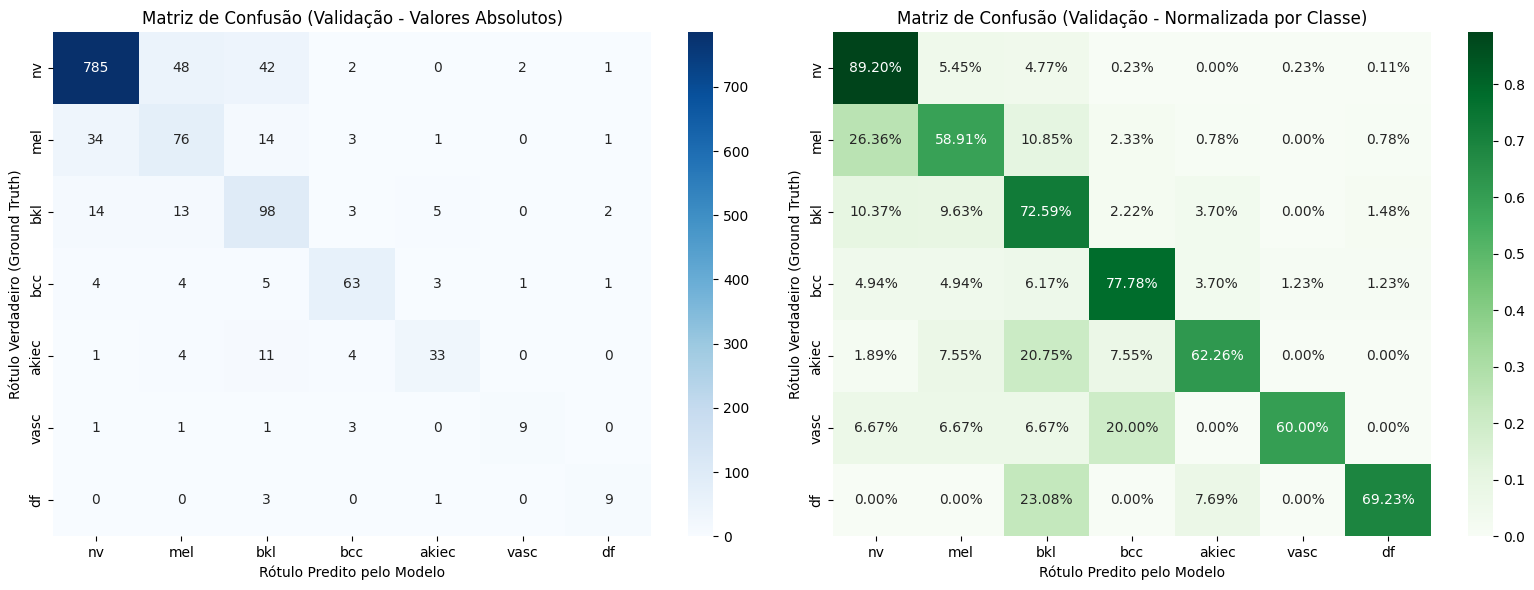

In [102]:

#CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

def evaluate_model(model, dataloader, device, class_names=CLASS_NAMES, dataset_type="Teste"):
    """
    Avalia o modelo calculando métricas detalhadas e exibindo a Matriz de Confusão.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    print(f"\nAvaliando no conjunto de {dataset_type}...")

    # Coleta das predições sem calcular gradientes
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc=f"Avaliando {dataset_type}"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # 1. Cálculo das Métricas Gerais
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    print(f"\n==================================================")
    print(f"📊 RESULTADOS DE AVALIAÇÃO - CONJUNTO DE {dataset_type.upper()}")
    print(f"==================================================")
    print(f"✨ Acurácia Balanceada: {bal_acc * 100:.2f}%\n")

    # 2. Relatório Detalhado por Classe (Precision, Recall, F1-Score)
    print("📋 Relatório de Classificação Detalhado:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # 3. Gerando e Plotando a Matriz de Confusão
    cm = confusion_matrix(all_labels, all_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalizada por linha (Ground Truth)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Contagem Absoluta de Amostras
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, ax=ax[0]
    )
    ax[0].set_title(f'Matriz de Confusão ({dataset_type} - Valores Absolutos)', fontsize=12)
    ax[0].set_ylabel('Rótulo Verdadeiro (Ground Truth)')
    ax[0].set_xlabel('Rótulo Predito pelo Modelo')

    # Gráfico 2: Percentual Normalizado por Classe
    sns.heatmap(
        cm_normalized, annot=True, fmt='.2%', cmap='Greens',
        xticklabels=class_names, yticklabels=class_names, ax=ax[1]
    )
    ax[1].set_title(f'Matriz de Confusão ({dataset_type} - Normalizada por Classe)', fontsize=12)
    ax[1].set_ylabel('Rótulo Verdadeiro (Ground Truth)')
    ax[1].set_xlabel('Rótulo Predito pelo Modelo')

    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUÇÃO DA AVALIAÇÃO (Rode para Validação e Teste)
# ==========================================

# 1. Avaliar na Validação
evaluate_model(new_model, valid_loader, device=device, dataset_type="Validação")

# 2. Avaliar no Teste (Descomente se tiver o test_loader definido)
# evaluate_model(new_model, test_loader, device=device, dataset_type="Teste")


Avaliando no conjunto de Teste...


Avaliando Teste:   0%|          | 0/48 [00:00<?, ?it/s]


📊 RESULTADOS DE AVALIAÇÃO - CONJUNTO DE TESTE
✨ Acurácia Balanceada: 70.49%

📋 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

          nv     0.9303    0.8799    0.9044      1016
         mel     0.5721    0.6183    0.5943       186
         bkl     0.6425    0.7209    0.6795       172
         bcc     0.5870    0.8182    0.6835        66
       akiec     0.6444    0.6042    0.6237        48
        vasc     0.8846    0.7931    0.8364        29
          df     0.5556    0.5000    0.5263        10

    accuracy                         0.8147      1527
   macro avg     0.6881    0.7049    0.6926      1527
weighted avg     0.8271    0.8147    0.8192      1527



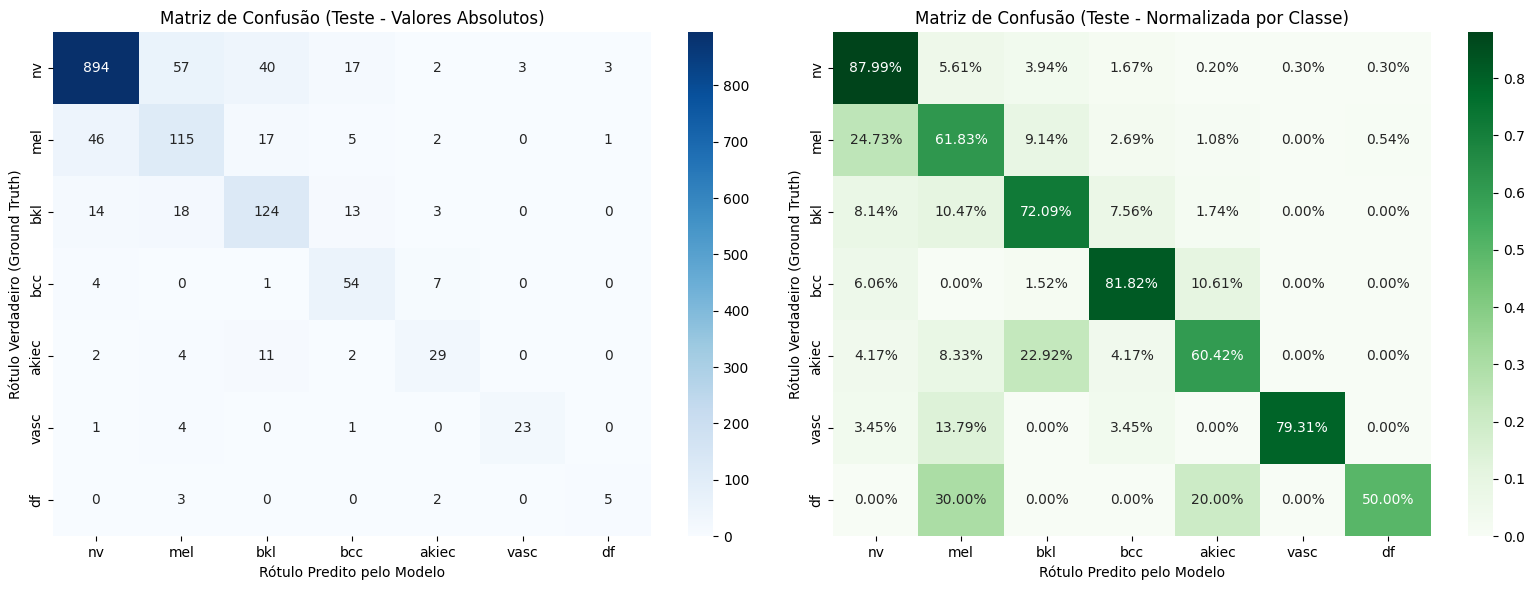

In [103]:
evaluate_model(new_model, test_loader, device=device, dataset_type="Teste")

# Avaliação, Interpretabilidade e Rastreamento de Experimentos

## liberando a memoria do ambiente

In [117]:
print(f"VRAM Alocada: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"VRAM Reservada: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

VRAM Alocada: 14.24 GB
VRAM Reservada: 15.45 GB


In [126]:
#del new_model

import gc

gc.collect()

torch.cuda.empty_cache()

In [127]:
print(f"VRAM Alocada: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"VRAM Reservada: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

VRAM Alocada: 1.25 GB
VRAM Reservada: 1.41 GB


## preparacao para interpretabilidade

In [9]:
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
import timm
import numpy as np

In [10]:
import subprocess
subprocess.run(["pip", "install", "captum", "lime", "grad-cam", "mlflow", "-q"], check=True)
print("Libs instaladas.")
#!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [16]:
# 1. Mapeamento das classes do HAM10000

CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Redefinição da Arquitetura (necessária para recriar a estrutura antes de injetar os pesos)
class HybridModel(nn.Module):
    def __init__(self, num_classes=7):
        super(HybridModel, self).__init__()
        self.cnn = timm.create_model('tf_efficientnetv2_s.in21k_ft_in1k', pretrained=False, num_classes=0)
        self.vit = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=0)

        num_ftrs_cnn = self.cnn.num_features  # 1280
        num_ftrs_vit = self.vit.num_features  # 768
        combined_features = num_ftrs_cnn + num_ftrs_vit

        self.classifier_head = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(p=0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        feat_cnn = self.cnn(x)
        feat_vit = self.vit(x)
        combined = torch.cat((feat_cnn, feat_vit), dim=1)
        return self.classifier_head(combined)

# 3. Função para Carregar o Modelo a partir do .pth
def load_trained_model(weights_path="best_hybrid_model.pth"):
    model = HybridModel(num_classes=7).to(device)

    # Carrega o dicionário de pesos do arquivo .pth
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)

    # Coloca o modelo em modo de avaliação (desativa Dropout e BatchNorm em treino)
    model.eval()
    print(f"✅ Modelo carregado com sucesso a partir de '{weights_path}'!")
    return model

# 4. Pipeline de Transformação da Imagem (Mesmo pré-processamento usado no treino)
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 5. Função de Inferencia / Predição
def predict_skin_lesion(image_path, model):
    # Carrega e transforma a imagem
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform_pipeline(image).unsqueeze(0).to(device) # Adiciona dimensão de batch [1, 3, 224, 224]

    # Executa a predição sem calcular gradientes
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0] # Converte para probabilidades (0 a 1)
        confidence, predicted_idx = torch.max(probabilities, 0)

    predicted_class = CLASS_NAMES[predicted_idx.item()]
    confidence_percent = confidence.item() * 100

    '''print(f"\n🔍 Diagnóstico Predito: {predicted_class.upper()}")
    print(f"🎯 Confiança do Modelo: {confidence_percent:.2f}%\n")

    # Exibe as probabilidades de todas as classes
    print("Probabilidades por classe:")
    for idx, prob in enumerate(probabilities):
        print(f" - {CLASS_NAMES[idx]}: {prob.item() * 100:.2f}%")'''

    return predicted_class, confidence_percent

# ==========================================
# EXEMPLO DE USO:
# ==========================================
# 1. Carregar modelo salvo
loaded_model = load_trained_model("/kaggle/working/bal_hybrid_model.pth")

✅ Modelo carregado com sucesso a partir de '/kaggle/working/bal_hybrid_model.pth'!


In [138]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

target_layers = [loaded_model.cnn.conv_head]

# 3. Pipeline de Transformação
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def apply_gradcam(image_path, model, target_class_idx=None):

    model.eval()

    # a) Carregar e preparar a imagem para exibição (Normalizada entre 0.0 e 1.0)
    raw_image = Image.open(image_path).convert('RGB').resize((224, 224))
    rgb_img_np = np.float32(raw_image) / 255.0  # [224, 224, 3]

    # b) Preparar o tensor de entrada para o PyTorch
    input_tensor = transform_pipeline(raw_image).unsqueeze(0).to(device)

    # c) Se a classe alvo não for informada, a predição do modelo será feita
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_idx = torch.argmax(probabilities).item()

    # Define a classe a ser explicada
    if target_class_idx is None:
        target_class_idx = predicted_idx

    targets = [ClassifierOutputTarget(target_class_idx)]

    cam = GradCAM(model=model, target_layers=target_layers)

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    visualization = show_cam_on_image(rgb_img_np, grayscale_cam, use_rgb=True)

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(rgb_img_np)
    ax[0].set_title(f"Imagem Original\nPredição: {CLASS_NAMES[predicted_idx].upper()} ({probabilities[predicted_idx].item()*100:.1f}%)")
    ax[0].axis('off')

    ax[1].imshow(visualization)
    ax[1].set_title(f"Grad-CAM - Foco na Classe: {CLASS_NAMES[target_class_idx].upper()}")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

In [139]:
sample_imgs, sample_labels = [], []
seen = set()

print("Coletando imagens de exemplo...")
for imgs, labels in test_loader:
    for img, label in zip(imgs, labels):
        l = label.item()
        if l not in seen:
            sample_imgs.append(img)
            sample_labels.append(l)
            seen.add(l)
        if len(seen) == 7: 
            break
    if len(seen) == 7: 
        break

print(f"Total de imagens coletadas: {len(sample_imgs)} (uma para cada classe)")

Coletando imagens de exemplo...
Total de imagens coletadas: 7 (uma para cada classe)


## Grad-cam

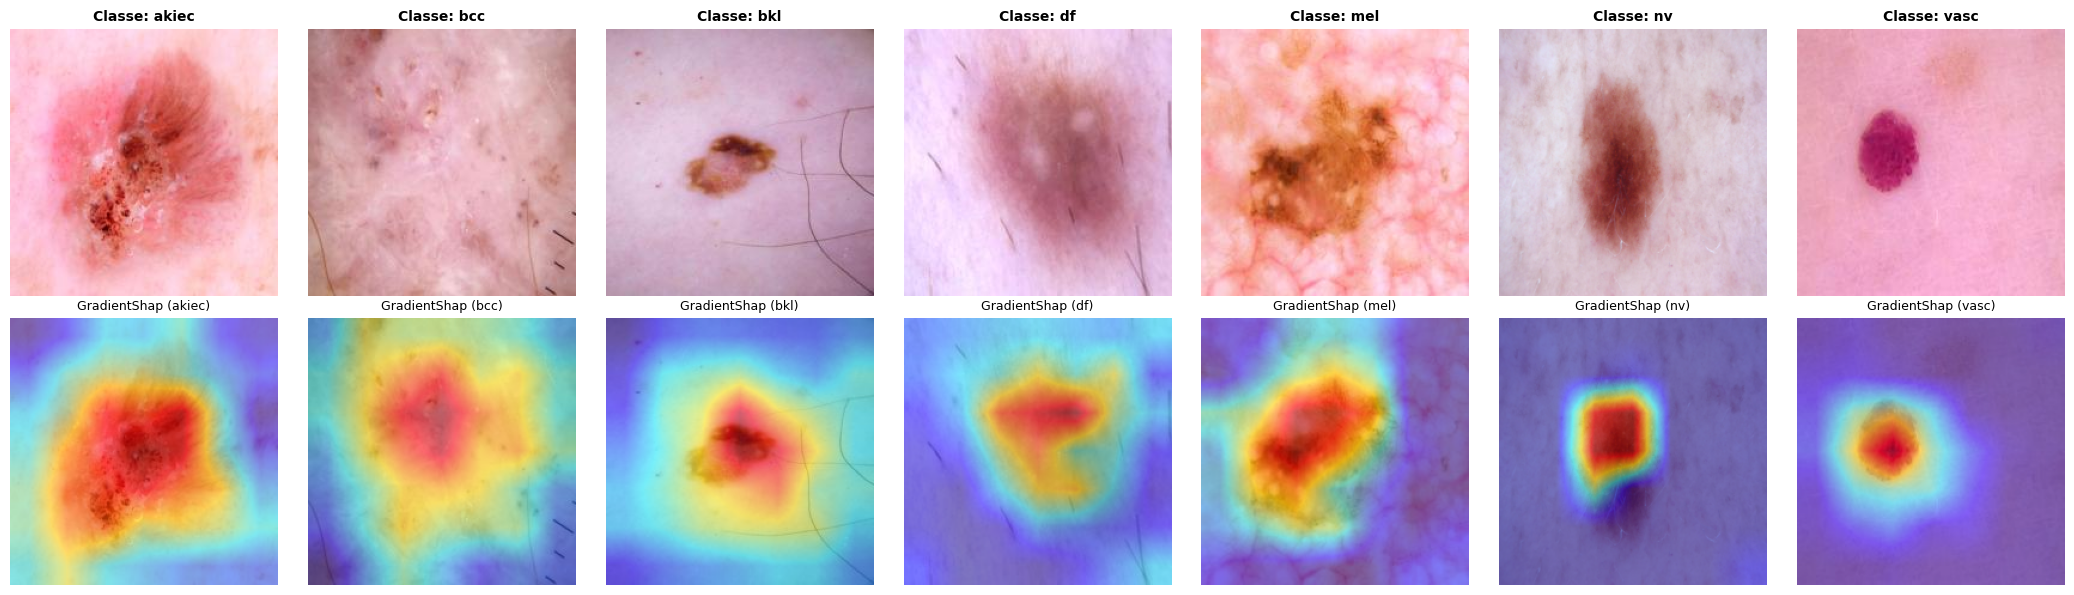

In [174]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']


target_layers = [loaded_model.cnn.conv_head]

# 3. Pipeline de Transformação
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def apply_gradcam(image_path, model, target_class_idx=None):

    model.eval()

    # a) Carregar e preparar a imagem para exibição (Normalizada entre 0.0 e 1.0)
    raw_image = Image.open(image_path).convert('RGB').resize((224, 224))
    rgb_img_np = np.float32(raw_image) / 255.0  # [224, 224, 3]

    # b) Preparar o tensor de entrada para o PyTorch
    input_tensor = transform_pipeline(raw_image).unsqueeze(0).to(device)

    # c) Se a classe alvo não for informada, a predição do modelo será feita
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_idx = torch.argmax(probabilities).item()

    # Define a classe a ser explicada
    if target_class_idx is None:
        target_class_idx = predicted_idx

    targets = [ClassifierOutputTarget(target_class_idx)]

    cam = GradCAM(model=model, target_layers=target_layers)

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    visualization = show_cam_on_image(rgb_img_np, grayscale_cam, use_rgb=True)

    return rgb_img_np, visualization


df_sample = df_train.groupby('dx').sample(n=1, random_state=42).reset_index()

fig, ax = plt.subplots(2, 7, figsize=(21, 6))

for idx, row in df_sample.iterrows():
    #print(f"Index: {idx}, Age: {row['filepath']}", row['label'])
    original, processada = apply_gradcam(row['filepath'], loaded_model, row['label'])

    ax[0, idx].imshow(original)
    ax[0, idx].set_title(f"Classe: {row['dx']}", fontsize=10, fontweight='bold')
    ax[0, idx].axis('off')


    ax[1, idx].imshow(processada)
    ax[1, idx].set_title(f"GradientShap ({row['dx']})", fontsize=9)
    ax[1, idx].axis('off')
    
plt.tight_layout()
plt.show()

### GradientSHAP

In [142]:
# Lista todas as variáveis definidas na sessão atual do Python
for var_name in dir():
    # Filtra para mostrar apenas objetos que parecem ser modelos do PyTorch
    if "model" in var_name.lower():
        print(f"Variável encontrada: {var_name}")

Variável encontrada: HybridModel
Variável encontrada: best_model_wts
Variável encontrada: evaluate_model
Variável encontrada: load_trained_model
Variável encontrada: loaded_model
Variável encontrada: modelo_para_explicar


Gerando mapas GradientSHAP...


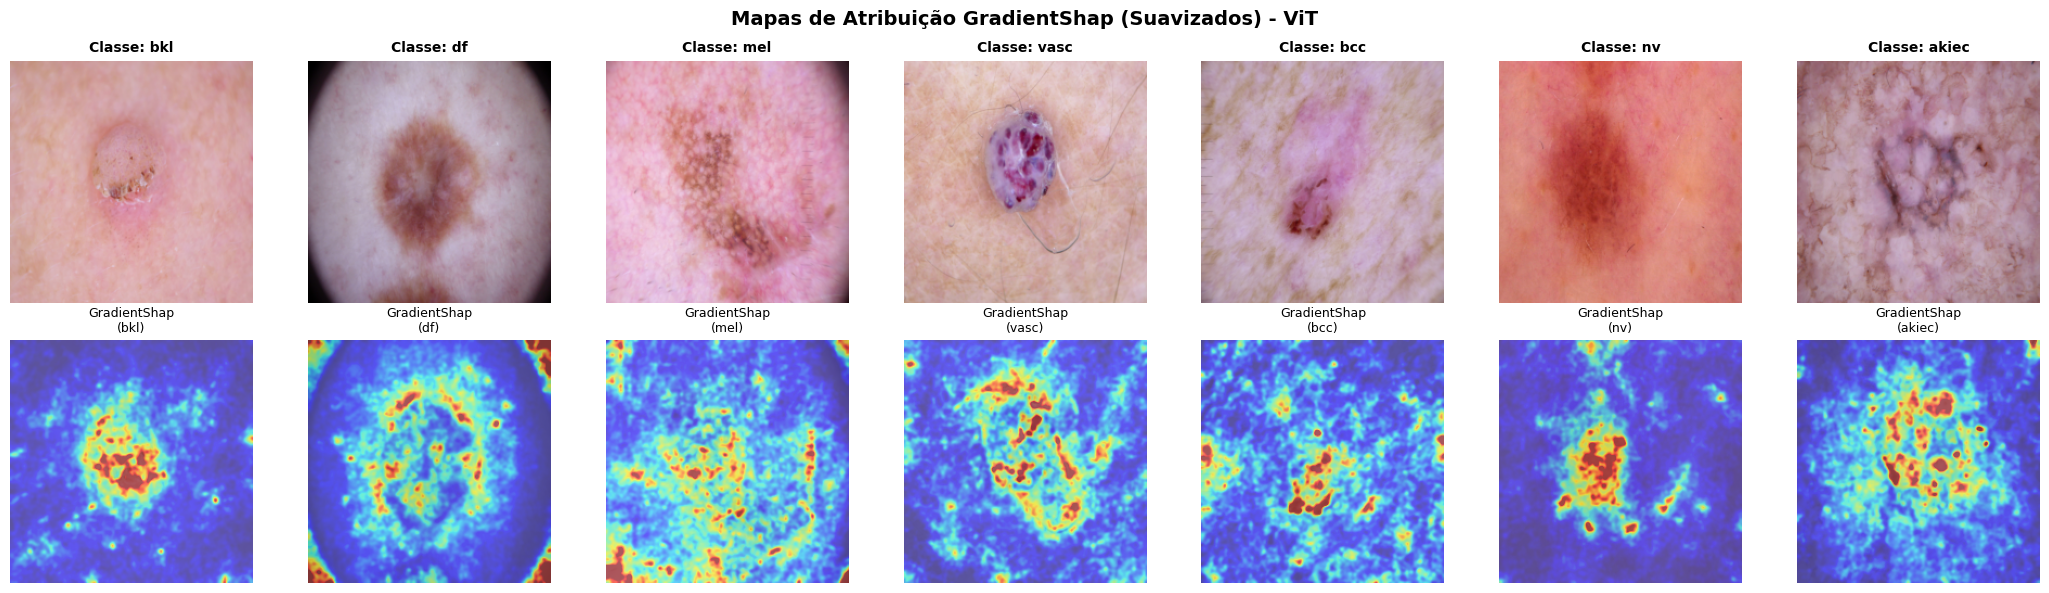

In [143]:
from scipy.ndimage import gaussian_filter
from captum.attr import GradientShap
import numpy as np

modelo_para_explicar = loaded_model
gradient_shap = GradientShap(modelo_para_explicar)

# Definindo mean e std usados na normalização do ImageNet
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 7, figsize=(21, 6))

print("Gerando mapas GradientSHAP...")

for i, (img_tensor, label) in enumerate(zip(sample_imgs, sample_labels)):
    input_tensor = img_tensor.unsqueeze(0).to(device)
    
    # Baseline preta
    baseline = torch.zeros_like(input_tensor)

    attributions = gradient_shap.attribute(
        input_tensor,
        baselines=baseline,
        target=label,
        n_samples=50,
        stdevs=0.1
    )

    attr = attributions.squeeze(0).cpu().permute(1, 2, 0).numpy()
    attr = np.abs(attr).sum(axis=2)
    
    # Suavizar para reduzir o efeito "patch" do ViT
    attr = gaussian_filter(attr, sigma=1.5)

    # Normalização robusta baseada em percentis
    v_min, v_max = np.percentile(attr, (1, 99))
    attr = np.clip((attr - v_min) / (v_max - v_min + 1e-8), 0, 1)

    # Preparar imagem original
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Plotar Imagem Original
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"Classe: {CLASS_NAMES[label]}", fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    # Plotar Mapa de Atribuição
    im = axes[1, i].imshow(img_np, alpha=0.5)
    im_attr = axes[1, i].imshow(attr, cmap='jet', alpha=0.6)
    axes[1, i].set_title(f"GradientShap\n({CLASS_NAMES[label]})", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle("Mapas de Atribuição GradientShap (Suavizados) - ViT", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("gradientshap_vit_smooth.png", dpi=300, bbox_inches='tight')
plt.show()

### LIME

Gerando mapas LIME (isso pode levar alguns instantes)...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

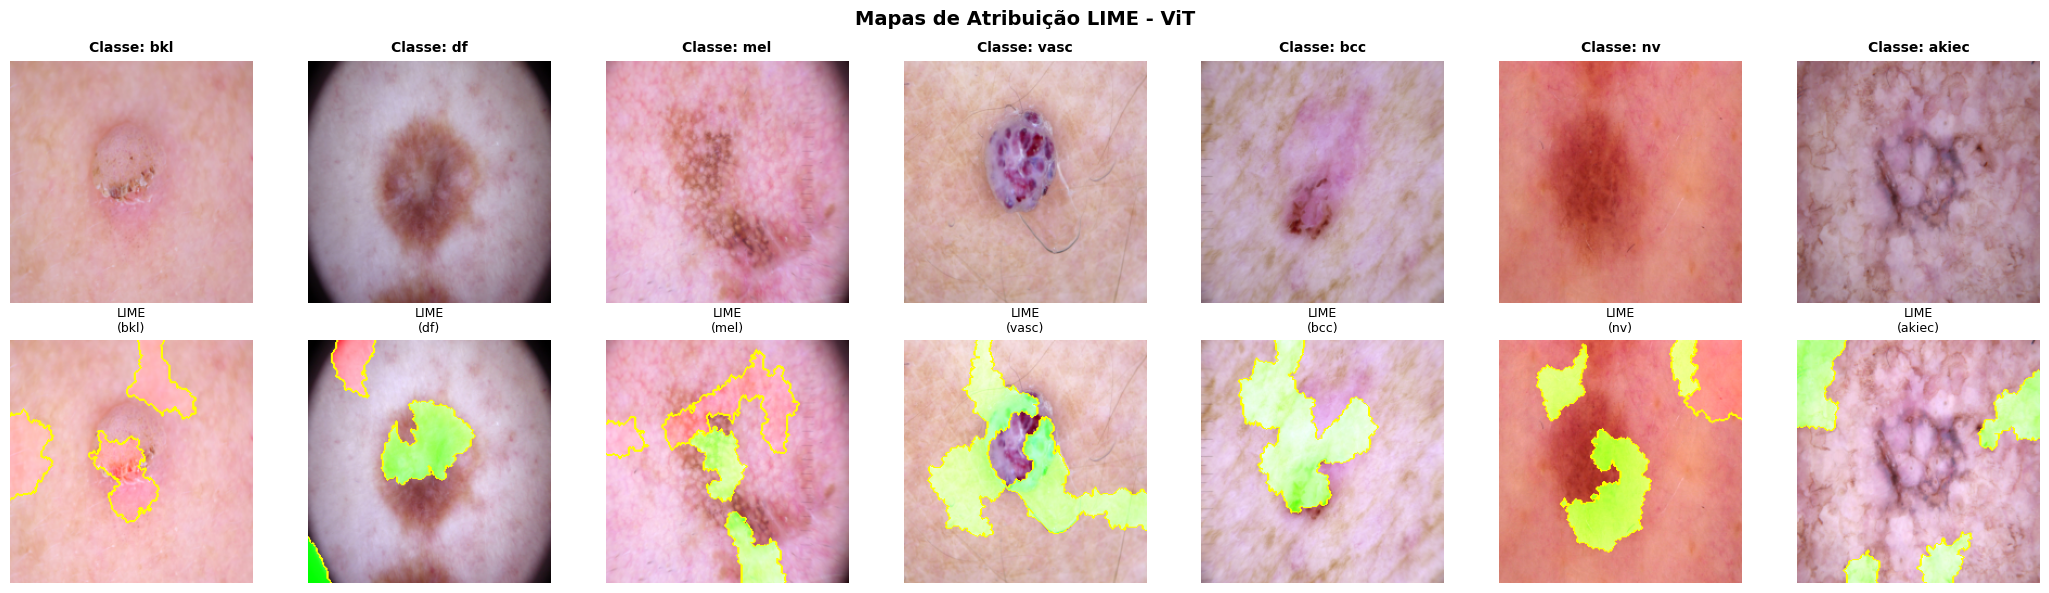

In [144]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Função de predição customizada para o LIME
def batch_predict(images):
    # Usando o nome correto do seu modelo carregado
    loaded_model.eval()
    batch_tensors = []
    
    for img in images:
        # Converter numpy para PIL Image
        pil_img = Image.fromarray((img * 255).astype(np.uint8))
        
        # Como estamos usando um modelo PyTorch puro (EfficientNet/Swin / HybridModel) 
        # e não o processador do Hugging Face, usamos o transform_pipeline diretamente:
        tensor = transform_pipeline(pil_img)
        batch_tensors.append(tensor)
        
    # Empilhar em um batch e enviar para o dispositivo (GPU/CPU)
    input_batch = torch.stack(batch_tensors).to(device)
    
    with torch.no_grad():
        outputs = loaded_model(input_batch)
        # Se o modelo retornar logits diretamente, aplicamos o softmax neles:
        probs = torch.softmax(outputs, dim=1)
        
    return probs.cpu().numpy()

# 2. Inicializar o explicador LIME para imagens
explainer = lime_image.LimeImageExplainer()

# Selecionar uma quantidade de imagens de exemplo (ex: as mesmas 7 classes se 'sample_imgs' existir)
if 'sample_imgs' not in locals() or len(sample_imgs) == 0:
    print("Coletando imagens de exemplo...")
    sample_imgs, sample_labels = [], []
    seen = set()
    for imgs, labels in test_loader:
        for img, label in zip(imgs, labels):
            l = label.item()
            if l not in seen:
                sample_imgs.append(img)
                sample_labels.append(l)
                seen.add(l)
            if len(seen) == 7: break
        if len(seen) == 7: break

# 3. Gerar e plotar as explicações LIME
fig, axes = plt.subplots(2, 7, figsize=(21, 6))
print("Gerando mapas LIME (isso pode levar alguns instantes)...")

for i, (img_tensor, label) in enumerate(zip(sample_imgs, sample_labels)):
    # Reverter a normalização do tensor para exibir a imagem original corretamente no LIME
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    # Explicar a instância com LIME
    # top_labels=1 explica a classe prevista; ou passamos target=label para a classe real
    explanation = explainer.explain_instance(
        img_np.astype(np.double), 
        batch_predict, 
        top_labels=7, 
        hide_color=0, 
        num_samples=100  # Número de perturbações (aumentar melhora a precisão, mas é mais lento)
    )
    
    # Obter a máscara para a classe real (label)
    temp, mask = explanation.get_image_and_mask(
        label, 
        positive_only=False,  # Mostra tanto regiões que apoiam quanto que contradizem
        num_features=5,       # Quantidade de superpíxeis destacados
        hide_rest=False
    )
    
    # Plotar Imagem Original
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"Classe: {CLASS_NAMES[label]}", fontsize=10, fontweight='bold')
    axes[0, i].axis('off')
    
    # Plotar a fronteira do LIME sobreposta à imagem
    axes[1, i].imshow(mark_boundaries(temp / temp.max(), mask))
    axes[1, i].set_title(f"LIME\n({CLASS_NAMES[label]})", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle("Mapas de Atribuição LIME - ViT", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("lime_vit_final.png", dpi=300, bbox_inches='tight')
plt.show()

### MLflow

In [145]:
import mlflow
from datetime import datetime
import os

# Configuração do Tracking
MLFLOW_DIR = "/kaggle/working/mlflow"
os.makedirs(MLFLOW_DIR, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DIR}/mlflow.db")
mlflow.set_experiment("skin-cancer-vit-ham10000")

# Verificar se as variáveis necessárias existem
if 'history' not in locals():
    raise NameError("O dicionário 'history' não foi encontrado. Execute a célula de treinamento primeiro.")
if 'model' not in locals() and 'loaded_model' not in locals():
    raise NameError("O modelo não foi encontrado. Execute o treinamento ou carregamento primeiro.")

# Usar o modelo carregado ou o treinado
current_model = loaded_model if 'loaded_model' in locals() else model

# Calcular métricas finais no teste (caso não tenha feito na célula de avaliação)
# Se já tiver a variável 'accuracy' da célula 23/24, pode usá-la diretamente.
best_val_acc = max(history["val_acc"])

run_name = f"vit_base_patch16_{datetime.now().strftime('%Y%m%d_%H%M')}"

print(f"Iniciando run MLflow: {run_name}...")

with mlflow.start_run(run_name=run_name):
    
    # 1. Logar Parâmetros (Ajustados para ViT)
    mlflow.log_params({
        "model_architecture": "google/vit-base-patch16-224",
        "classifier_head": "Custom MLP (768->512->256->7)",
        "num_classes": 7,
        "batch_size": 32, # Ajuste se tiver usado outro valor
        "total_epochs": len(history["train_loss"]),
        "optimizer": "AdamW",
        "learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "image_size": 224,
        "augmentation": "Auto (HuggingFace ViT Processor)",
        "freeze_backbone": True
    })

    # 2. Logar Melhores Métricas
    mlflow.log_metric("best_val_accuracy", best_val_acc)
    mlflow.log_metric("best_val_loss", min(history["val_loss"]))
    
    # Se tiver calculado a acurácia no teste na célula anterior:
    if 'accuracy' in locals():
        mlflow.log_metric("test_accuracy", accuracy)

    # 3. Logar Histórico por Época
    epochs = len(history["train_loss"])
    for i in range(epochs):
        mlflow.log_metrics({
            "train_loss": history["train_loss"][i],
            "train_acc": history["train_acc"][i],
            "val_loss": history["val_loss"][i],
            "val_acc": history["val_acc"][i],
            "val_f1": history["val_f1"][i] if "val_f1" in history else 0.0
        }, step=i+1)

    # 4. Logar Artefatos (Modelo e Imagens)
    # Salvar o modelo novamente para garantir que o arquivo existe para o MLflow
    model_path = "best_vit_ham10000_mlflow.pth"
    torch.save(current_model.state_dict(), model_path)
    mlflow.log_artifact(model_path)
    
    # Lista de imagens possíveis (loga apenas as que existirem)
    images_to_log = [
        "gradcam_vit_final.png", 
        "gradientshap_vit.png",  
        "lime_vit_final.png",    
        "gradcam.png",           
        "gradientshap.png",
        "lime.png"
    ]
    
    for img_file in images_to_log:
        if os.path.exists(img_file):
            mlflow.log_artifact(img_file)
            print(f"Artefato logado: {img_file}")
        else:
            print(f"Arquivo não encontrado (ignorado): {img_file}")

    print("\nRun registrado no MLflow com sucesso!")
    print(f"Melhor val_accuracy: {best_val_acc:.4f}")
    print(f"URI da Run: {mlflow.active_run().info.artifact_uri}")

2026/08/02 21:45:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/02 21:45:07 INFO mlflow.store.db.utils: Updating database tables


Iniciando run MLflow: vit_base_patch16_20260802_2145...
Arquivo não encontrado (ignorado): gradcam_vit_final.png
Arquivo não encontrado (ignorado): gradientshap_vit.png
Artefato logado: lime_vit_final.png
Arquivo não encontrado (ignorado): gradcam.png
Arquivo não encontrado (ignorado): gradientshap.png
Arquivo não encontrado (ignorado): lime.png

Run registrado no MLflow com sucesso!
Melhor val_accuracy: 0.8407
URI da Run: /kaggle/working/mlruns/1/9389d1160c4b4c99ad7889f9a7338a01/artifacts


# Análise Demográfica

In [17]:
classe_predita = []
confianca = []
for idx, row in df_test.iterrows():
    #print(idx, row['filepath'])
    cl, per = predict_skin_lesion( row['filepath'], loaded_model)
    classe_predita.append(cl)
    confianca.append(per)

In [22]:
df_analitic = df_test.copy()
df_analitic['pred'] = classe_predita
df_analitic['confiaca'] = confianca
df_analitic['acerto'] = df_analitic['pred'] == df_analitic['dx']

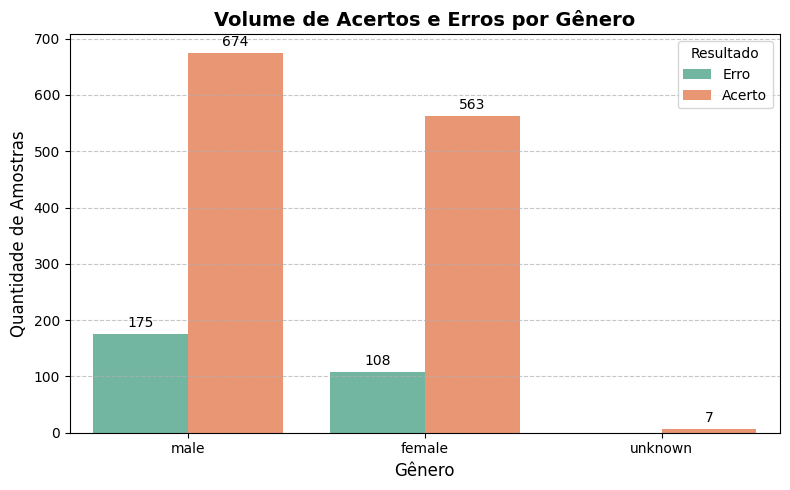

In [31]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_analitic, x='sex', hue='acerto', palette='Set2')

# Ajusta as legendas
plt.title('Volume de Acertos e Erros por Gênero', fontsize=14, fontweight='bold')
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Quantidade de Amostras', fontsize=12)
plt.legend(title='Resultado', labels=['Erro', 'Acerto'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Opcional: Adiciona o valor exato acima de cada barra
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

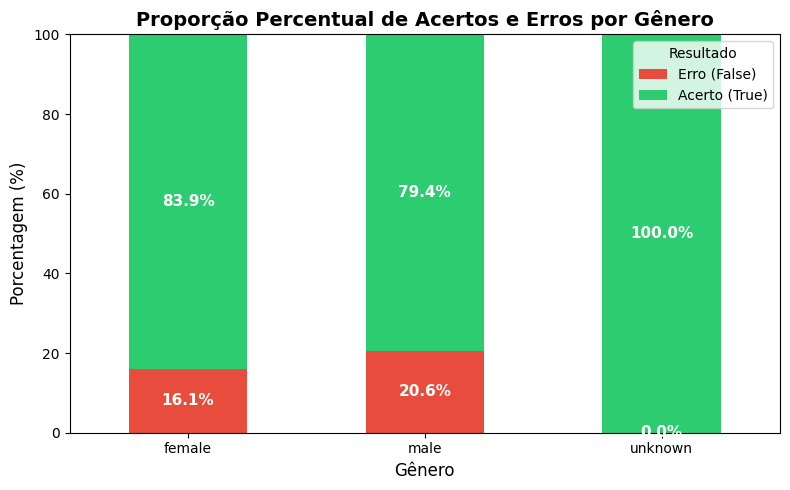

In [32]:

# 1. Calcula a proporção percentual de acertos/erros por gênero
df_prop = (
    df_analitic.groupby('sex')['acerto']
    .value_counts(normalize=True)
    .unstack() * 100
)

# 2. Plota as barras empilhadas
fig, ax = plt.subplots(figsize=(8, 5))
df_prop.plot(
    kind='bar', 
    stacked=True, 
    color=['#e74c3c', '#2ecc71'], 
    ax=ax, 
    width=0.5
)

# Ajustes estéticos e rótulos das porcentagens
plt.title('Proporção Percentual de Acertos e Erros por Gênero', fontsize=14, fontweight='bold')
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Resultado', labels=['Erro (False)', 'Acerto (True)'], loc='upper right')
plt.ylim(0, 100)

# Adiciona o texto com a % dentro de cada segmento
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

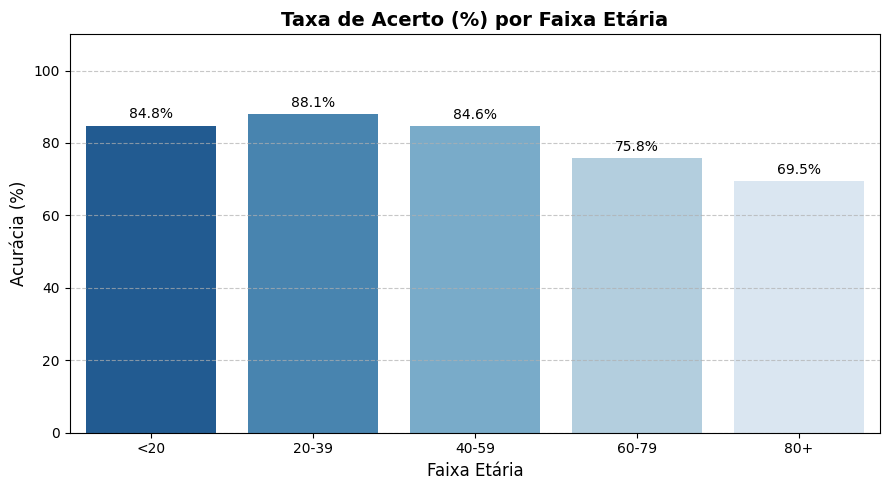

In [34]:

# 1. Cria as faixas etárias
bins = [0, 20, 40, 60, 80, 100]
labels = ['<20', '20-39', '40-59', '60-79', '80+']
df_analitic['faixa_etaria'] = pd.cut(df_analitic['age'], bins=bins, labels=labels, right=False)

# 2. Calcula a taxa de acerto (%) por faixa etária
df_acc_age = (
    df_analitic.groupby('faixa_etaria', observed=False)['acerto']
    .mean()
    .reset_index()
)
df_acc_age['acerto_pct'] = df_acc_age['acerto'] * 100

# 3. Plota o gráfico de barras
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_acc_age, 
    x='faixa_etaria', 
    y='acerto_pct', 
    hue='faixa_etaria', 
    palette='Blues_r'
)

# Remove a legenda gerada pelo hue e adiciona os rótulos de %
if ax.legend_:
    ax.legend_.remove()

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Taxa de Acerto (%) por Faixa Etária', fontsize=14, fontweight='bold')
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()